# Memanfaatkan Fear & Greed Index (FGI) untuk Menekan Drawdown

**Permintaan**: strategi B (filter tren BTC SMA100, notebook 12) masih punya drawdown ±35–39% dan tahun
negatif. Cari perbaikan memakai indikator lain dan **wajib memanfaatkan FGI**.

### Protokol (sudah ±536 konfigurasi dicoba sebelumnya → risiko pola palsu tinggi)
- Hipotesis ditetapkan dari **teori**, ambang FGI memakai definisi standar alternative.me
  (≤ 25 *extreme fear*, ≥ 75 *extreme greed*, 50 = netral). Semua hipotesis yang dicoba dicatat di sini,
  termasuk yang gagal.
- Dievaluasi di **3 periode**: 2018-03 → 2020-12, 2021 → 2023, 2024-01 → 2026-06. Kandidat harus
  **konsisten di ketiganya**, bukan juara di satu periode.
- Mesin eksposur harian (`run_exposure`): porsi BTC 0–100% diputuskan di close, berlaku dari open besok,
  biaya 0.15% × perubahan porsi. Semua strategi (termasuk B) dijalankan dengan mesin yang sama.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, run_exposure, metrics, BTC

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 60)
P = Panel({BTC: load_symbol(BTC, "1d", "full")}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
c = P.close[BTC]
sma = lambda n: c.rolling(n, min_periods=n).mean()
PER = {"2018-20": ("2018-03-01", "2020-12-31"), "2021-23": ("2021-01-01", "2023-12-31"), "2024-26": ("2024-01-01", "2026-06-30")}
print(f"FGI tersedia {fgi.first_valid_index().date()} → {fgi.last_valid_index().date()}")

FGI tersedia 2018-02-01 → 2026-06-30


## 1. Seberapa "baru" informasi FGI?

FGI alternative.me dihitung dari volatilitas, momentum/volume, media sosial, dominasi BTC, dan Google
Trends — sebagian besar turunan dari **harga**. Kalau FGI hampir sama dengan tren harga, ia sulit
menambah nilai di atas filter tren.

return BTC 30 hari       0.70
jarak harga ke SMA100    0.82
jarak harga ke SMA50     0.77
volatilitas 30 hari     -0.16


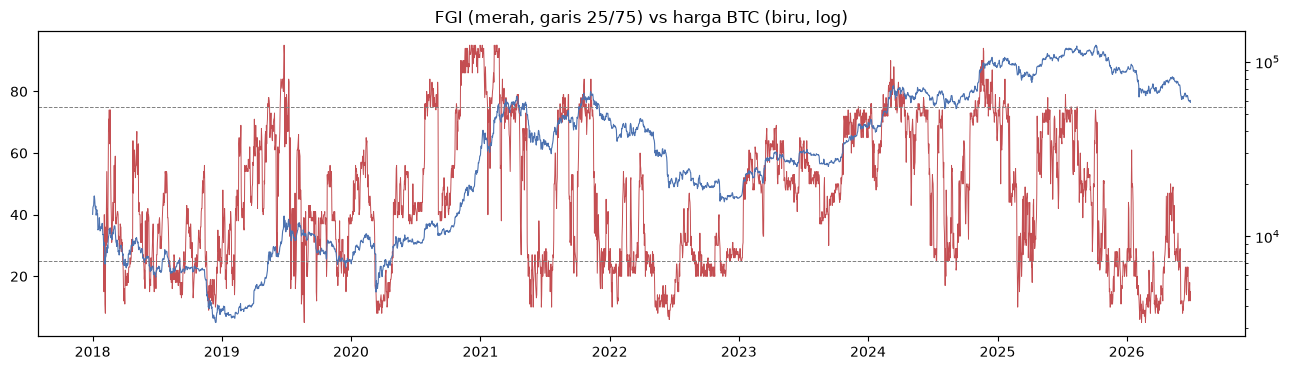

In [2]:
corr = pd.Series({
    "return BTC 30 hari": fgi.corr(c.pct_change(30)),
    "jarak harga ke SMA100": fgi.corr(c / sma(100) - 1),
    "jarak harga ke SMA50": fgi.corr(c / sma(50) - 1),
    "volatilitas 30 hari": fgi.corr(c.pct_change().rolling(30).std()),
}).rename("korelasi dengan FGI")
print(corr.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(fgi.index, fgi, lw=0.7, color="#C44E52", label="FGI")
ax.axhline(25, ls="--", lw=0.7, color="gray"); ax.axhline(75, ls="--", lw=0.7, color="gray")
ax2 = ax.twinx(); ax2.plot(c.index, c, lw=0.8, color="#4C72B0", label="BTC"); ax2.set_yscale("log")
ax.set_title("FGI (merah, garis 25/75) vs harga BTC (biru, log)"); plt.tight_layout(); plt.show()

## 2. Semua hipotesis yang diuji

| Kode | Aturan | Teori |
|---|---|---|
| B | pegang BTC saat close > SMA100 (baseline notebook 12) | tren |
| H1 | B, tapi cash saat FGI ≥ 75 / ≥ 80 | euforia = puncak |
| H2 | beli saat FGI ≤ 20/25, jual saat FGI ≥ 50/75 (tanpa filter tren) | kontrarian |
| H3 | B **atau** (FGI ≤ 20/25 **dan** close > SMA20) | masuk dini di dasar yang mulai memantul |
| H4a–d | B × porsi berdasarkan FGI (takut → porsi besar, serakah → porsi kecil) | kontrarian dalam tren |
| H5 | B **dan** SMA50 > SMA100 (golden cross) | kurangi sinyal palsu |
| H6 | B, tapi cash saat volatilitas 20 hari > persentil-80 setahun | crash = volatilitas tinggi |
| H7 | pegang saat rata-rata FGI 14 hari > 50 (rezim sentimen, tanpa harga) | sentimen sebagai rezim |
| H8 | B **dan** FGI 14 hari > 50 | konfirmasi sentimen |
| **H8b** | B **atau** FGI 14 hari > 50 | sentimen pulih lebih dulu dari harga |

In [3]:
trend = (c > sma(100)).astype(float)
f14 = fgi.rolling(14).mean()

def hold_state(enter, exit_):
    s, out = False, []
    for e, x in zip(enter.fillna(False), exit_.fillna(False)):
        s = True if (not s and e) else (False if (s and x) else s)
        out.append(float(s))
    return pd.Series(out, index=P.dates)

def fgi_steps(levels):
    conds = [fgi < t for t, _ in levels[:-1]]
    return pd.Series(np.select(conds, [w for _, w in levels[:-1]], levels[-1][1]), index=P.dates)

vol = c.pct_change().rolling(20).std()
volhi = vol > vol.rolling(365, min_periods=180).quantile(0.8)

H = {
    "B  tren SMA100": trend,
    "H1 tren & FGI<75": trend * (fgi < 75),
    "H1 tren & FGI<80": trend * (fgi < 80),
    "H2 beli FGI<=20, jual FGI>=50": hold_state(fgi <= 20, fgi >= 50),
    "H2 beli FGI<=25, jual FGI>=50": hold_state(fgi <= 25, fgi >= 50),
    "H2 beli FGI<=20, jual FGI>=75": hold_state(fgi <= 20, fgi >= 75),
    "H2 beli FGI<=25, jual FGI>=75": hold_state(fgi <= 25, fgi >= 75),
    "H3 tren ATAU (FGI<=20 & >SMA20)": ((trend > 0) | ((fgi <= 20) & (c > sma(20)))).astype(float),
    "H3 tren ATAU (FGI<=25 & >SMA20)": ((trend > 0) | ((fgi <= 25) & (c > sma(20)))).astype(float),
    "H4a tren x {<50:1,<75:.5,else .25}": trend * fgi_steps([(50, 1), (75, .5), (None, .25)]),
    "H4b tren x {<50:1,<75:.5,else 0}": trend * fgi_steps([(50, 1), (75, .5), (None, 0)]),
    "H4c tren x {<25:1,<50:.75,<75:.5,else .25}": trend * fgi_steps([(25, 1), (50, .75), (75, .5), (None, .25)]),
    "H4d tren x clip((100-FGI)/50,.25,1)": trend * ((100 - fgi) / 50).clip(.25, 1),
    "H5 tren & SMA50>SMA100": trend * (sma(50) > sma(100)),
    "H6 tren & bukan vol ekstrem": trend * (~volhi),
    "H7 FGI 14h > 50": (f14 > 50).astype(float),
    "H8 tren & FGI 14h > 50": trend * (f14 > 50),
    "H8b tren ATAU FGI 14h > 50": ((trend > 0) | (f14 > 50)).astype(float),
    "BTC hold": pd.Series(1.0, index=P.dates),
}
N_TRIALS_HERE = len(H) - 2   # tanpa B & BTC hold (sudah dihitung sebelumnya)

rows, eqs = [], {}
for name, w in H.items():
    r = dict(strategi=name)
    for pn, per in PER.items():
        tr, eq = run_exposure(P, w, *per)
        m = metrics(tr, eq); eqs[(name, pn)] = eq
        r[f"{pn} return"], r[f"{pn} DD"], r[f"{pn} Sharpe"] = m["total_return"], m["max_dd"], m["sharpe"]
    r["porsi rata2"] = run_exposure(P, w, "2018-03-01", "2026-06-30")[1].attrs["avg_weight"]
    rows.append(r)
res = pd.DataFrame(rows).set_index("strategi")
b = res.loc["B  tren SMA100"]
res["Sharpe >= B di 3 periode"] = [all(res.at[i, f"{p} Sharpe"] >= b[f"{p} Sharpe"] - 1e-9 for p in PER) for i in res.index]
res["DD <= B di 3 periode"] = [all(res.at[i, f"{p} DD"] >= b[f"{p} DD"] - 1e-9 for p in PER) for i in res.index]
out = res.copy()
for col in out.columns:
    if "return" in col or "DD" in col and "3 periode" not in col:
        out[col] = out[col].map(lambda v: f"{v:+.0%}")
    elif "Sharpe" in col and "3 periode" not in col or col == "porsi rata2":
        out[col] = out[col].map(lambda v: f"{v:.2f}")
out

,2018-20 return,2018-20 DD,2018-20 Sharpe,2021-23 return,2021-23 DD,2021-23 Sharpe,2024-26 return,2024-26 DD,2024-26 Sharpe,porsi rata2,Sharpe >= B di 3 periode,DD <= B di 3 periode
strategi,,,,,,,,,,,,
B tren SMA100,+346%,-35%,1.35,+149%,-39%,0.90,+49%,-37%,0.65,0.53,True,True
H1 tren & FGI<75,+110%,-33%,0.86,+78%,-37%,0.71,+20%,-28%,0.42,0.42,False,True
H1 tren & FGI<80,+104%,-33%,0.81,+64%,-37%,0.61,+31%,-37%,0.50,0.47,False,False
"H2 beli FGI<=20, jual FGI>=50",+36%,-57%,0.48,-50%,-62%,-0.30,-4%,-37%,0.10,0.38,False,False
"H2 beli FGI<=25, jual FGI>=50",-7%,-65%,0.24,-51%,-63%,-0.29,-5%,-38%,0.09,0.41,False,False
"H2 beli FGI<=20, jual FGI>=75",-35%,-73%,0.09,+10%,-69%,0.33,-7%,-45%,0.08,0.67,False,False
"H2 beli FGI<=25, jual FGI>=75",-35%,-73%,0.09,-0%,-73%,0.27,-23%,-51%,-0.13,0.70,False,False
H3 tren ATAU (FGI<=20 & >SMA20),+353%,-44%,1.35,+137%,-40%,0.85,+68%,-37%,0.77,0.55,False,False
H3 tren ATAU (FGI<=25 & >SMA20),+381%,-41%,1.37,+91%,-53%,0.69,+66%,-37%,0.76,0.57,False,False


## 3. Perbandingan adil untuk ukuran posisi berbasis FGI (H4)

H4 menurunkan drawdown — tapi juga menurunkan porsi rata-rata (≈0.27–0.40 vs B 0.51). Pembanding
yang adil: **B dengan porsi tetap** yang rata-ratanya sama. Kalau B-porsi-tetap lebih baik, FGI tidak
menambah informasi — cuma "memegang BTC lebih sedikit".

In [4]:
rows = []
for name in [k for k in H if k.startswith("H4")]:
    k = res.at[name, "porsi rata2"] / res.at["B  tren SMA100", "porsi rata2"]
    fixed = trend * k
    for label, w in ((name, H[name]), (f"   B porsi tetap {k:.0%}", fixed)):
        r = dict(strategi=label)
        for pn, per in PER.items():
            m = metrics(*run_exposure(P, w, *per))
            r[f"{pn} return"], r[f"{pn} DD"], r[f"{pn} Sharpe"] = f"{m['total_return']:+.0%}", f"{m['max_dd']:+.0%}", f"{m['sharpe']:.2f}"
        rows.append(r)
pd.DataFrame(rows).set_index("strategi")

,2018-20 return,2018-20 DD,2018-20 Sharpe,2021-23 return,2021-23 DD,2021-23 Sharpe,2024-26 return,2024-26 DD,2024-26 Sharpe
strategi,,,,,,,,,
"H4a tren x {<50:1,<75:.5,else .25}",+67%,-29%,0.76,+70%,-33%,0.84,+8%,-20%,0.28
B porsi tetap 56%,+151%,-20%,1.35,+80%,-24%,0.90,+30%,-22%,0.65
"H4b tren x {<50:1,<75:.5,else 0}",+36%,-28%,0.52,+53%,-33%,0.71,+1%,-20%,0.11
B porsi tetap 51%,+133%,-18%,1.35,+72%,-22%,0.90,+27%,-20%,0.65
"H4c tren x {<25:1,<50:.75,<75:.5,else .25}",+83%,-21%,0.95,+72%,-26%,0.92,+14%,-16%,0.43
B porsi tetap 51%,+132%,-18%,1.35,+72%,-22%,0.90,+27%,-20%,0.65
"H4d tren x clip((100-FGI)/50,.25,1)",+105%,-30%,0.89,+63%,-35%,0.67,+19%,-25%,0.44
B porsi tetap 73%,+215%,-25%,1.35,+106%,-30%,0.90,+38%,-28%,0.65


## 4. Kandidat H8b — uji overfitting

H8b satu-satunya hipotesis dengan **Sharpe ≥ B di ketiga periode**. Uji:
1. **Uji nol**: ganti sinyal FGI 14h > 50 dengan sinyal acak yang punya pola hidup/mati sama
   (panjang periode diacak), tetap di-OR dengan tren. Apakah FGI lebih baik dari acak?
2. **Deflated Sharpe** dengan jumlah percobaan total ±536 + hipotesis di notebook ini.
3. Return per tahun.

In [5]:
def shuffled_like(sig, rng):
    runs = sig.ne(sig.shift()).cumsum()
    segs = [(bool(v.iloc[0]), len(v)) for _, v in sig.groupby(runs)]
    on = [l for s, l in segs if s]; off = [l for s, l in segs if not s]
    a, bb = list(rng.permutation(on)), list(rng.permutation(off))
    state, seq = segs[0][0], []
    while a or bb:
        if (state and a) or not bb:
            seq += [True] * int(a.pop())
        else:
            seq += [False] * int(bb.pop())
        state = not state
    return pd.Series(seq, index=sig.index)

FULL = ("2018-03-01", "2026-06-30")
sig = (f14 > 50)[FULL[0]:FULL[1]]
real = metrics(*run_exposure(P, H["H8b tren ATAU FGI 14h > 50"], *FULL))["sharpe"]
base = metrics(*run_exposure(P, H["B  tren SMA100"], *FULL))["sharpe"]
rng = np.random.default_rng(0); null = []
for _ in range(500):
    rs = shuffled_like(sig, rng).reindex(P.dates).fillna(False)
    null.append(metrics(*run_exposure(P, ((trend > 0) | rs).astype(float), *FULL))["sharpe"])
null = np.array(null)
print(f"Periode penuh 2018-03 → 2026-06")
print(f"  Sharpe B (tren saja)            : {base:.2f}")
print(f"  Sharpe H8b (tren ATAU FGI>50)   : {real:.2f}")
print(f"  Sharpe tren ATAU sinyal acak    : median {np.median(null):.2f}, p95 {np.percentile(null, 95):.2f}")
print(f"  p-value (acak >= H8b)           : {(null >= real).mean():.1%}")

Periode penuh 2018-03 → 2026-06
  Sharpe B (tren saja)            : 1.02
  Sharpe H8b (tren ATAU FGI>50)   : 1.07
  Sharpe tren ATAU sinyal acak    : median 0.79, p95 0.99
  p-value (acak >= H8b)           : 0.4%


In [6]:
def daily_sharpe(r):
    r = np.asarray(r); return r.mean() / r.std() if r.std() > 0 else 0.0

def expected_max_sharpe(n, var_sr):
    g = 0.5772156649
    return np.sqrt(var_sr) * ((1 - g) * stats.norm.ppf(1 - 1 / n) + g * stats.norm.ppf(1 - 1 / (n * np.e)))

def dsr(r, sr0):
    r = np.asarray(r); sr = daily_sharpe(r)
    sk, ku = stats.skew(r), stats.kurtosis(r, fisher=False)
    return stats.norm.cdf((sr - sr0) * np.sqrt(len(r) - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2))

TEST = PER["2024-26"]
test_sr = [daily_sharpe(run_exposure(P, w, *TEST)[1].pct_change().dropna()) for w in H.values()]
var_sr = np.var(test_sr)
N_TOTAL = 536 + N_TRIALS_HERE
rows = []
for name in ("B  tren SMA100", "H8b tren ATAU FGI 14h > 50"):
    r = run_exposure(P, H[name], *TEST)[1].pct_change().dropna()
    for n in (1, N_TRIALS_HERE, N_TOTAL):
        sr0 = expected_max_sharpe(n, var_sr) if n > 1 else 0.0
        rows.append(dict(strategi=name, n_percobaan=n, sharpe=daily_sharpe(r) * np.sqrt(365),
                         batas_kebetulan=sr0 * np.sqrt(365), DSR=dsr(r, sr0)))
d = pd.DataFrame(rows).set_index(["strategi", "n_percobaan"])
d.assign(sharpe=d.sharpe.round(2), batas_kebetulan=d.batas_kebetulan.round(2), DSR=d.DSR.map(lambda v: f"{v:.0%}"))

sharpe  batas_kebetulan  DSR
strategi                   n_percobaan                              
B  tren SMA100             1              0.65             0.00  85%
                           17             0.65             0.50  59%
                           553            0.65             0.84  38%
H8b tren ATAU FGI 14h > 50 1              0.82             0.00  91%
                           17             0.82             0.50  70%
                           553            0.82             0.84  49%

In [7]:
yr = {}
for name in ("B  tren SMA100", "H8b tren ATAU FGI 14h > 50", "BTC hold"):
    _, eq = run_exposure(P, H[name], *FULL)
    yr[name] = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
t = pd.DataFrame(yr).T
t.columns = [f"{y}{' (Mar-)' if y == 2018 else (' (-Jun)' if y == 2026 else '')}" for y in t.columns]
t.map(lambda v: f"{v:+.0%}")

,2018 (Mar-),2019,2020,2021,2022,2023,2024,2025,2026 (-Jun)
B tren SMA100,-28%,+133%,+166%,+74%,-21%,+81%,+56%,+3%,-8%
H8b tren ATAU FGI 14h > 50,-31%,+134%,+188%,+70%,-21%,+89%,+89%,+1%,-8%
BTC hold,-66%,+89%,+302%,+58%,-65%,+154%,+112%,-7%,-34%


## 5. Menekan "minus": anggaran risiko (porsi tetap)

Hasil bagian 3: cara paling efektif menurunkan drawdown **bukan** mengatur porsi pakai FGI, tapi
**memegang porsi tetap yang lebih kecil** (sisanya cash/stablecoin). Sharpe tetap sama, drawdown dan return
turun bersamaan. Ini **pilihan selera risiko**, bukan optimasi — tabel di bawah untuk memilih.

In [8]:
rows = []
for name in ("B  tren SMA100", "H8b tren ATAU FGI 14h > 50"):
    for k in (1.0, 0.75, 0.6, 0.5):
        r = dict(strategi=name.strip(), porsi=f"{k:.0%}")
        for pn, per in PER.items():
            m = metrics(*run_exposure(P, H[name] * k, *per))
            r[f"{pn} profit/thn"] = f"{m['cagr']:+.0%}"
            r[f"{pn} DD"] = f"{m['max_dd']:+.0%}"
        _, eq = run_exposure(P, H[name] * k, *FULL)
        yrs = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
        r["tahun terburuk"] = f"{yrs.min():+.0%}"
        rows.append(r)
pd.DataFrame(rows).set_index(["strategi", "porsi"])

2018-20 profit/thn 2018-20 DD 2021-23 profit/thn 2021-23 DD 2024-26 profit/thn 2024-26 DD tahun terburuk
strategi                   porsi                                                                                                         
B  tren SMA100             100%                +69%       -35%               +36%       -39%               +17%       -37%           -28%
                           75%                 +52%       -26%               +28%       -30%               +14%       -28%           -22%
                           60%                 +41%       -21%               +23%       -25%               +12%       -23%           -18%
                           50%                 +34%       -18%               +19%       -21%               +10%       -20%           -15%
H8b tren ATAU FGI 14h > 50 100%                +72%       -36%               +36%       -39%               +26%       -32%           -31%
                           75%                 +54%       -27%               +29%       -30%               +20%       -25%           -24%
                           60%                 +42%       -22%               +24%       -25%               +17%       -20%           -19%
                           50%                 +35%       -19%               +20%       -21%               +14%       -17%           -16%

## Kesimpulan

### 1. Peran FGI yang terbukti: **sinyal masuk lebih awal** (H8b)
Aturan **H8b**: pegang BTC kalau **close > SMA100 ATAU rata-rata FGI 14 hari > 50**, selain itu cash.

| | 2018–20 | 2021–23 | 2024–26 |
|---|---|---|---|
| Sharpe B → **H8b** | 1.35 → **1.39** | 0.90 → **0.90** | 0.65 → **0.82** |
| Return B → **H8b** | +346% → **+368%** | +149% → **+154%** | +49% → **+78%** |
| Drawdown B → H8b | −35% → −36% | −39% → −39% | −37% → **−32%** |

- Satu-satunya dari 17 hipotesis dengan **Sharpe ≥ B di ketiga periode**.
- **Uji nol**: sinyal FGI > 50 mengalahkan sinyal acak berpola sama (**p = 0.4%**, periode 2018–2026)
  → FGI benar-benar menambah informasi: sentimen sering pulih **sebelum** harga menembus SMA100.
- Tapi perbaikannya **moderat** (Sharpe penuh 1.02 → 1.07) dan Deflated Sharpe 49% setelah 553
  percobaan → belum signifikan kuat secara statistik.

### 2. Peran FGI yang **tidak** bekerja
- **Beli saat takut ekstrem saja (H2)**: rugi di hampir semua variasi (−50% di 2021–23) — sama dengan
  kegagalan V5. Takut ekstrem tanpa konfirmasi tren = menangkap pisau jatuh.
- **Jual saat euforia (H1)**: memotong keuntungan bull market.
- **Porsi berdasarkan FGI (H4)**: drawdown turun, tapi **kalah dari B dengan porsi tetap** yang
  rata-ratanya sama (mis. H4a Sharpe 0.76/0.84/0.28 vs B-porsi-tetap 1.35/0.90/0.65). FGI berkorelasi
  **0.82** dengan jarak harga ke SMA100, jadi sebagian besar hanya mengulang informasi tren.

### 3. Menekan "minus" → **porsi tetap lebih kecil** (sisanya cash/stablecoin)
Drawdown **tidak bisa dihilangkan**; yang bisa: memilih seberapa besar. H8b dengan porsi tetap:

| Porsi | Profit/tahun (3 periode) | Max drawdown | Tahun terburuk |
|---|---|---|---|
| 100% | +26% s/d +72% | −32% s/d −39% | −31% |
| 75% | +20% s/d +54% | −25% s/d −30% | −24% |
| **60%** | **+17% s/d +42%** | **−20% s/d −25%** | **−19%** |
| 50% | +14% s/d +35% | −17% s/d −21% | −16% |

### Rekomendasi aturan final
1. Setiap hari setelah close: **risk-on** kalau close BTC > SMA100 **atau** rata-rata FGI 14 hari > 50;
   selain itu **cash**.
2. Saat risk-on, pegang **BTC dengan porsi tetap** sesuai selera risiko — **60%** memberi drawdown
   ±20–25% (dari ±35–39%), sisa 40% di stablecoin.
3. Eksekusi di open berikutnya. Tidak ada parameter yang perlu dioptimasi lagi.
4. **Paper trading ke depan** tetap wajib sebelum modal riil.